# **BERTimbau - Modelo de Analise de Sentimento na lingua portuguesa**

--------
## Usando pipeline pré-treinado: model="stevillis/bertimbau-finetuned-glassdoor-reviews"
-------

REFERENCIA:
stevillis. (2025). bertimbau-finetuned-glassdoor-reviews [Modelo de classificação de sentimento]. https://huggingface.co/stevillis/bertimbau-finetuned-glassdoor-reviews

In [1]:
# ==========================================
# Bibliotecas
# ==========================================
import pandas as pd
import json
import plotly.graph_objects as go
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

from transformers import pipeline

from IPython.display import display

d:\Programs\Python 3.12.0\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# ==========================================
# Mostra o texto completo em cada célula
# ==========================================
pd.set_option("display.max_colwidth", None)  

In [3]:
df = pd.read_pickle('Reviews_BERTimbau_base.pkl')
df.head()

,date,comments,cidade,lang,texto_limpo,Base-analise_sentimento,Base-sentimento,Base-confianca
0,2025-06-23,"Os anfitriões são maravilhosos, a casa é um charme com macaquinhos vindo toda manhã na varanda, porém considerando ter muitos móveis velhos e objetos pessoais acaba ficando com cheiro forte de coisa guardada e fechada",Rio de Janeiro,pt,"Os anfitriões são maravilhosos, a casa é um charme com macaquinhos vindo toda manhã na varanda, porém considerando ter muitos móveis velhos e objetos pessoais acaba ficando com cheiro forte de coisa guardada e fechada","{'label': 'POSITIVO', 'score': 0.4085640013217926}",POSITIVO,0.408564
1,2022-05-02,"A estadia com o Renato foi a melhor experiência no Airbnb até hoje .<br/>Vou falar 4 coisas que não poderia deixar passar.<br/>01- A vista da cobertura é sensacional , um ângulo de visão da Bahia de Guanabara , Pão de Açucar , Aeroporto Santos Dumont e Cristo Redentor é sensacional.<br/>02- A recepção no Chek-in foi indescritível , fomos recebidos com algumas surpresas que me deixaram de queixo caído , uma delas é de uma simpatia sem igual, mas não posso contar a vocês porque perderia a graça.<br/>03- A flexibilidade na reserva e as dicas do RJ que o Renato passa , são maravilhosas.<br/>04- A localização do apartamento é fantástica pois fica pórximo a tudo.<br/>Enfim , Super indico o Renato para se hospedarem , o Apartamento é fantastico !!!",Rio de Janeiro,pt,"A estadia com o Renato foi a melhor experiência no Airbnb até hoje . Vou falar coisas que não poderia deixar passar. - A vista da cobertura é sensacional , um ângulo de visão da Bahia de Guanabara , Pão de Açucar , Aeroporto Santos Dumont e Cristo Redentor é sensacional. - A recepção no Chek-in foi indescritível , fomos recebidos com algumas surpresas que me deixaram de queixo caído , uma delas é de uma simpatia sem igual, mas não posso contar a vocês porque perderia a graça. - A flexibilidade na reserva e as dicas do RJ que o Renato passa , são maravilhosas. - A localização do apartamento é fantástica pois fica pórximo a tudo. Enfim , Super indico o Renato para se hospedarem , o Apartamento é fantastico ! ! !","{'label': 'NEGATIVO', 'score': 0.4087783396244049}",NEGATIVO,0.408778
2,2025-08-18,"o apt do Maurício é otimo!!! tudo nele nos encantou. o prédio, os porteiros, o apt, a gentileza, a localização, enfim, um lugar com a cara do Rio e da gentileza e bom gosto do carioca",Rio de Janeiro,pt,"o apt do Maurício é otimo! ! ! tudo nele nos encantou. o prédio, os porteiros, o apt, a gentileza, a localização, enfim, um lugar com a cara do Rio e da gentileza e bom gosto do carioca","{'label': 'NEGATIVO', 'score': 0.4266848862171173}",NEGATIVO,0.426685
3,2024-05-02,"muito organizado, bonito, limpo, funcional. anfitrião atencioso, os melhores horários de check-in e checkout que já vi. gelo, café, toalhas, roupa de cama tudo que precisei tinha. Supermercado e farmácia perto, excelente. a vila estava um pouco barulhenta a noite, mas entendo que isso está fora do controle do anfitrião. umica recomendação seria um insulfim espelhado na porta. mas pq eu sou mais sensível a claridade mesmo.",Rio de Janeiro,pt,"muito organizado, bonito, limpo, funcional. anfitrião atencioso, os melhores horários de check-in e checkout que já vi. gelo, café, toalhas, roupa de cama tudo que precisei tinha. Supermercado e farmácia perto, excelente. a vila estava um pouco barulhenta a noite, mas entendo que isso está fora do controle do anfitrião. umica recomendação seria um insulfim espelhado na porta. mas pq eu sou mais sensível a claridade mesmo.","{'label': 'NEGATIVO', 'score': 0.40583062171936035}",NEGATIVO,0.405831
4,2024-09-17,"Incrível! Amei tudo. Super rápida em soluções e respostas. Localização melhor, impossível!",Rio de Janeiro,pt,"Incrível! Amei tudo. Super rápida em soluções e respostas. Localização melhor, impossível!","{'label': 'POSITIVO', 'score': 0.4076005816459656}",POSITIVO,0.407601


In [4]:
# ==========================================
# Criar pipeline de análise de sentimento
# ==========================================
classifier = pipeline(
    "sentiment-analysis",
    model="stevillis/bertimbau-finetuned-glassdoor-reviews",
    device=-1  # usar GPU se disponível (0), ou -1 para CPU
)

# ==========================================
# Aplicar análise de sentimento
# ==========================================
def analizar_sentimento_lote(textos, lote_size=16):
    resultados = []
    for i in range(0, len(textos), lote_size):
        lote = textos[i:i+lote_size]
        resultado_lote = classifier(lote, truncation=True, max_length=512) # Adicionar truncation=True e max_length=512
        resultados.extend(resultado_lote)
    return resultados

# Aplicar na coluna de texto
df['Stev_analise_sentimento'] = analizar_sentimento_lote(df['texto_limpo'].astype(str).tolist())

# ==========================================
# Extrair label e score
# ==========================================
df['Stev-sentimento'] = df['Stev_analise_sentimento'].apply(lambda x: x['label'])
df['Stev-confianca'] = df['Stev_analise_sentimento'].apply(lambda x: x['score'])

# ==========================================
# Verificar resultados
# ==========================================
display(df[['texto_limpo', 'Stev-sentimento', 'Stev-confianca']].head(10))
print("\nDistribuição de sentimentos:")
print(df['Stev-sentimento'].value_counts())

# ==========================================
# salvar resultados
# ==========================================
df.to_pickle("Reviews_BERTimbau_stevillis.pkl")

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 3822.39it/s]


,texto_limpo,Stev-sentimento,Stev-confianca
0,"Os anfitriões são maravilhosos, a casa é um charme com macaquinhos vindo toda manhã na varanda, porém considerando ter muitos móveis velhos e objetos pessoais acaba ficando com cheiro forte de coisa guardada e fechada",positive,0.964260
1,"A estadia com o Renato foi a melhor experiência no Airbnb até hoje . Vou falar coisas que não poderia deixar passar. - A vista da cobertura é sensacional , um ângulo de visão da Bahia de Guanabara , Pão de Açucar , Aeroporto Santos Dumont e Cristo Redentor é sensacional. - A recepção no Chek-in foi indescritível , fomos recebidos com algumas surpresas que me deixaram de queixo caído , uma delas é de uma simpatia sem igual, mas não posso contar a vocês porque perderia a graça. - A flexibilidade na reserva e as dicas do RJ que o Renato passa , são maravilhosas. - A localização do apartamento é fantástica pois fica pórximo a tudo. Enfim , Super indico o Renato para se hospedarem , o Apartamento é fantastico ! ! !",positive,0.994228
2,"o apt do Maurício é otimo! ! ! tudo nele nos encantou. o prédio, os porteiros, o apt, a gentileza, a localização, enfim, um lugar com a cara do Rio e da gentileza e bom gosto do carioca",positive,0.997476
3,"muito organizado, bonito, limpo, funcional. anfitrião atencioso, os melhores horários de check-in e checkout que já vi. gelo, café, toalhas, roupa de cama tudo que precisei tinha. Supermercado e farmácia perto, excelente. a vila estava um pouco barulhenta a noite, mas entendo que isso está fora do controle do anfitrião. umica recomendação seria um insulfim espelhado na porta. mas pq eu sou mais sensível a claridade mesmo.",positive,0.915490
4,"Incrível! Amei tudo. Super rápida em soluções e respostas. Localização melhor, impossível!",positive,0.996749
5,"Estadia perfeita no Leblon! A acomodação superou todas as expectativas: limpa, aconchegante, bem decorada e com uma localização excelente. Fomos muito bem recebidos, e cada detalhe fez a diferença. Ideal para quem quer aproveitar o Rio com conforto e tranquilidade. Com certeza voltaremos!",positive,0.997239
6,"Lugar maravilhoso, ótima localização!",positive,0.998026
7,"Tudo conforme o combinado, apartamento bem localizado, aconchegante, anfitriã atenciosa, cumpre os compromissos e auxilia em tudo que foi de sua possibilidade. Recomendo.",positive,0.997930
8,Sem palavras para descrever o quanto foi incrível estar nesse AP. Marisa é uma pessoa ímpar o que deixa esse AP mais impressionante ainda! Parabéns Marisa eu e minha namorada somos seus fãs,positive,0.976193
9,"A estadia no imóvel foi excelente. Vera sempre muito solícita, a localização no melhor ponto da Barra. Eu e minha família gostamos muito e com certeza voltaremos.",positive,0.997951



Distribuição de sentimentos:
Stev-sentimento
positive    188951
negative      7272
neutral       3777
Name: count, dtype: int64


In [5]:
df.head()

,date,comments,cidade,lang,texto_limpo,Base-analise_sentimento,Base-sentimento,Base-confianca,Stev_analise_sentimento,Stev-sentimento,Stev-confianca
0,2025-06-23,"Os anfitriões são maravilhosos, a casa é um charme com macaquinhos vindo toda manhã na varanda, porém considerando ter muitos móveis velhos e objetos pessoais acaba ficando com cheiro forte de coisa guardada e fechada",Rio de Janeiro,pt,"Os anfitriões são maravilhosos, a casa é um charme com macaquinhos vindo toda manhã na varanda, porém considerando ter muitos móveis velhos e objetos pessoais acaba ficando com cheiro forte de coisa guardada e fechada","{'label': 'POSITIVO', 'score': 0.4085640013217926}",POSITIVO,0.408564,"{'label': 'positive', 'score': 0.964259922504425}",positive,0.964260
1,2022-05-02,"A estadia com o Renato foi a melhor experiência no Airbnb até hoje .<br/>Vou falar 4 coisas que não poderia deixar passar.<br/>01- A vista da cobertura é sensacional , um ângulo de visão da Bahia de Guanabara , Pão de Açucar , Aeroporto Santos Dumont e Cristo Redentor é sensacional.<br/>02- A recepção no Chek-in foi indescritível , fomos recebidos com algumas surpresas que me deixaram de queixo caído , uma delas é de uma simpatia sem igual, mas não posso contar a vocês porque perderia a graça.<br/>03- A flexibilidade na reserva e as dicas do RJ que o Renato passa , são maravilhosas.<br/>04- A localização do apartamento é fantástica pois fica pórximo a tudo.<br/>Enfim , Super indico o Renato para se hospedarem , o Apartamento é fantastico !!!",Rio de Janeiro,pt,"A estadia com o Renato foi a melhor experiência no Airbnb até hoje . Vou falar coisas que não poderia deixar passar. - A vista da cobertura é sensacional , um ângulo de visão da Bahia de Guanabara , Pão de Açucar , Aeroporto Santos Dumont e Cristo Redentor é sensacional. - A recepção no Chek-in foi indescritível , fomos recebidos com algumas surpresas que me deixaram de queixo caído , uma delas é de uma simpatia sem igual, mas não posso contar a vocês porque perderia a graça. - A flexibilidade na reserva e as dicas do RJ que o Renato passa , são maravilhosas. - A localização do apartamento é fantástica pois fica pórximo a tudo. Enfim , Super indico o Renato para se hospedarem , o Apartamento é fantastico ! ! !","{'label': 'NEGATIVO', 'score': 0.4087783396244049}",NEGATIVO,0.408778,"{'label': 'positive', 'score': 0.9942275285720825}",positive,0.994228
2,2025-08-18,"o apt do Maurício é otimo!!! tudo nele nos encantou. o prédio, os porteiros, o apt, a gentileza, a localização, enfim, um lugar com a cara do Rio e da gentileza e bom gosto do carioca",Rio de Janeiro,pt,"o apt do Maurício é otimo! ! ! tudo nele nos encantou. o prédio, os porteiros, o apt, a gentileza, a localização, enfim, um lugar com a cara do Rio e da gentileza e bom gosto do carioca","{'label': 'NEGATIVO', 'score': 0.4266848862171173}",NEGATIVO,0.426685,"{'label': 'positive', 'score': 0.9974761605262756}",positive,0.997476
3,2024-05-02,"muito organizado, bonito, limpo, funcional. anfitrião atencioso, os melhores horários de check-in e checkout que já vi. gelo, café, toalhas, roupa de cama tudo que precisei tinha. Supermercado e farmácia perto, excelente. a vila estava um pouco barulhenta a noite, mas entendo que isso está fora do controle do anfitrião. umica recomendação seria um insulfim espelhado na porta. mas pq eu sou mais sensível a claridade mesmo.",Rio de Janeiro,pt,"muito organizado, bonito, limpo, funcional. anfitrião atencioso, os melhores horários de check-in e checkout que já vi. gelo, café, toalhas, roupa de cama tudo que precisei tinha. Supermercado e farmácia perto, excelente. a vila estava um pouco barulhenta a noite, mas entendo que isso está fora do controle do anfitrião. umica recomendação seria um insulfim espelhado na porta. mas pq eu sou mais sensível a claridade mesmo.","{'label': 'NEGATIVO', 'score': 0.40583062171936035}",NEGATIVO,0.405831,"{'label': 'positive', 'score': 0.9154902696609497}",positive,0.915490
4,2024-09-17,

In [ ]:
# ==========================================
# Ordem desejada
# ==========================================
ordem_sentimento = ['positive', 'negative', 'neutral']

# ==========================================
# Lista para juntar as amostras
# ==========================================
partes = []

# ==========================================
# Percorrer por sentimento e depois por cidade
# ==========================================
for sentimento in ordem_sentimento:
    for cidade in sorted(df['cidade'].dropna().unique()):
        subset = df[(df['Stev-sentimento'] == sentimento) & (df['cidade'] == cidade)]

        if len(subset) > 0:
            amostra = subset[['Base-sentimento', 'Stev-sentimento', 'cidade', 'texto_limpo']].sample(
                n=min(50, len(subset)),
                random_state=42
            )
            partes.append(amostra)

# ==========================================
# Juntar tudo
# ==========================================
amostras = pd.concat(partes, ignore_index=True)

# ==========================================
# Ordenar por sentimento e depois por cidade
# ==========================================
amostras['Stev-sentimento'] = pd.Categorical(amostras['Stev-sentimento'], categories=ordem_sentimento, ordered=True)
amostras = amostras.sort_values(['Stev-sentimento', 'cidade']).reset_index(drop=True)

with pd.option_context('display.max_rows', None, 'display.max_columns', None):
    display(amostras)

# ==========================================
# Salvar a amostra
# ==========================================
amostras.to_csv('Stevillis-amostras_50_por_sentimento_cidade.csv', index=False, encoding='utf-8-sig')

,Base-sentimento,Stev-sentimento,cidade,texto_limpo
0,POSITIVO,positive,Lisboa,"Adoramos a casa de Rui e Elsa, eles foram claros e rápidos nas nossas comunicações, achei o apartamento ainda mais bonito do que eu esperava pelas fotos, todo renovado, comportou muito bem meu grupo de pessoas, com espaço e conforto. Nos permitiram deixar as malas no apartamento antes do check in e achei ótimo que as coisas básicas como sabão para lavar roupas, detergente, papel higiênico, temperos estavam inclusos, o que evita o nosso gasto com coisas que não serão utilizadas no resto da viagem. Gostei da localização; pelo que vi em Lisboa, se você está perto do metro, você está perto de tudo. Obs. Importante notar que para pessoas com dificuldades motoras pode não ser a melhor opção, uma vez que tem escada para chegar ao apartamento e uns - minutos de caminhada em ruas de pedras."
1,POSITIVO,positive,Lisboa,"A estadia no apartamento de Filipa foi maravilhosa. Tudo estava como descrito no anúncio, limpeza e organização impecáveis. Sempre atenciosa, respondia rapidamente nossas dúvidas. Vamos voltar, com certeza! E recomendo muito!"
2,NEGATIVO,positive,Lisboa,"O apartamento bastante espaçoso, moderno, com todas as necessidades para uma boa estadia. Local tranquilo e proximo a estação do metro de Picoas. Pedro foi bastante simpático e atencioso."
3,POSITIVO,positive,Lisboa,Gostamos da Zona e o apartamento é muito limpo e aconchegante. A Fátima é uma anfitriã muito colaborativo e discreta.
4,POSITIVO,positive,Lisboa,Apartamento com quartos ideal para famílias. O local ideal para uma estadia em Lisboa. Havemos de repetir!
5,NEGATIVO,positive,Lisboa,Óptimo como sempre
6,POSITIVO,positive,Lisboa,"O apartamento é excelente. A localização é muito boa, próximo ao metrô e a diversos pontos de ônibus. Muito fácil chegar. Checkin e checkout realizados de maneira rápida e fácil."
7,POSITIVO,positive,Lisboa,Ótima localização. O proprietário foi excepcional. Muito atencioso. Recomendo muito.
8,POSITIVO,positive,Lisboa,"Para quem precisa de um local próximo do aeroporto , é perfeito."
9,POSITIVO,positive,Lisboa,"Gostamos muito do apartamento, grande com muita luz, com tudo que se necesita numa estadia fora de casa, zona calma e tranquila, perto de tudo, muito fácil acesso e fácil estacionamento. A Shauna foi muito prestativa e sempre atenta as nossas necessidades. Recomendo vivamente."


In [12]:
# ==========================================
# Agrupar por cidade e sentimento, contando as ocorrências
# ==========================================
tabela_cidade = df_stev.groupby(['cidade', 'Stev-sentimento']).size().unstack(fill_value=0)

# ==========================================
# Garantir ordem das colunas
# ==========================================
ordem = ['positive', 'negative', 'neutral']
tabela_cidade = tabela_cidade.reindex(columns=[c for c in ordem if c in tabela_cidade.columns], fill_value=0)

# ==========================================
# Adicionar total por cidade
# ==========================================
tabela_cidade['Total'] = tabela_cidade.sum(axis=1)

# ==========================================
# Criar tabela de percentagens por cidade
# ==========================================
cidade_percentagem = tabela_cidade[tabela_cidade.columns[:-1]].div(tabela_cidade['Total'], axis=0) * 100
cidade_percentagem = cidade_percentagem.round(1)
cidade_percentagem.columns = [f'{col}%' for col in cidade_percentagem.columns]
cidade_percentagem['Total%'] = 100.0

# ==========================================
# Juntar contagem e percentagem
# ==========================================
tabela_final = pd.concat([tabela_cidade, cidade_percentagem], axis=1)

# ==========================================
# Ordenar por total (opcional)
# ==========================================
tabela_final = tabela_final.sort_values('Total', ascending=False)

# ==========================================
# Mostrar tabela
# ==========================================
tabela_final = tabela_final.reset_index()
display(tabela_final)

# ==========================================
# Salvar a tabela
# ==========================================
tabela_final.to_csv('tabela_sentimentos_cidade_percentagem.csv')
print("\nTabela salva em 'tabela_sentimentos_cidade_percentagem.csv'")

,cidade,positive,negative,neutral,Total,positive%,negative%,neutral%,Total%
0,Lisboa,92739,4707,2554,100000,92.7,4.7,2.6,100.0
1,Rio de Janeiro,96212,2565,1223,100000,96.2,2.6,1.2,100.0



Tabela salva em 'tabela_sentimentos_cidade_percentagem.csv'


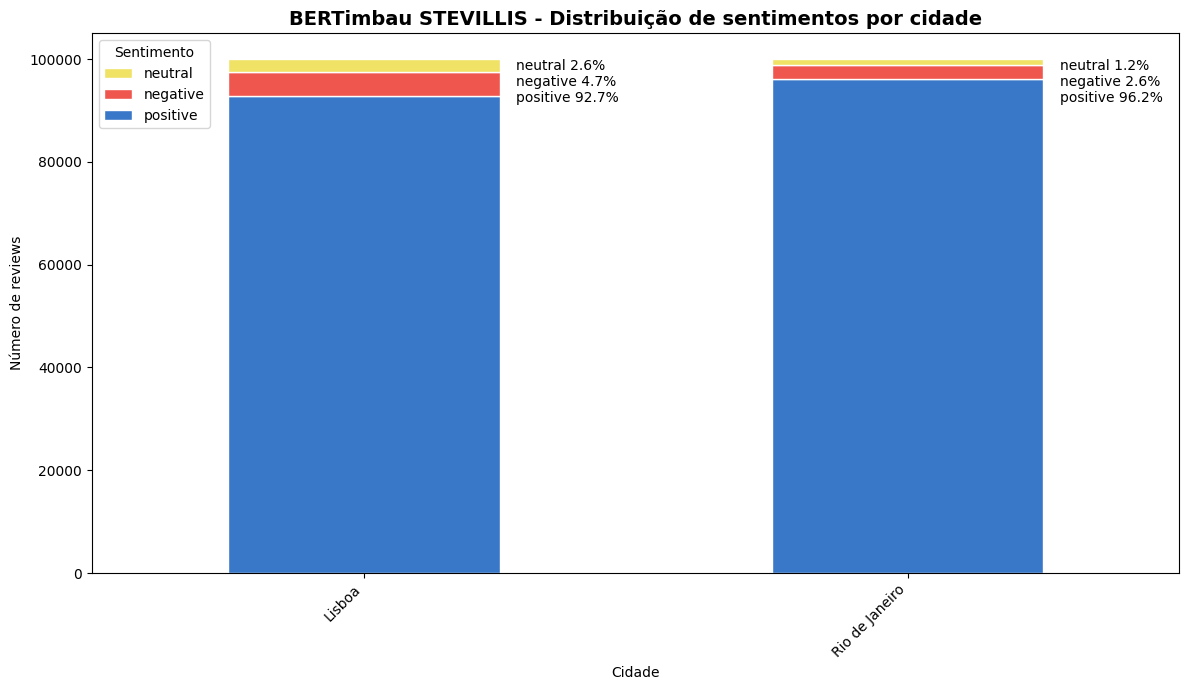

In [13]:
# ==========================================
# Agrupar por cidade e sentimento
# ==========================================
dados_cidade = df_stev.groupby(['cidade', 'Stev-sentimento']).size().unstack(fill_value=0)

# ==========================================
# Garantir ordem das colunas
# ==========================================
ordem = ['positive', 'negative', 'neutral']
dados_cidade = dados_cidade.reindex(columns=[c for c in ordem if c in dados_cidade.columns], fill_value=0)

# ==========================================
# Cores
# ==========================================
cores = {
    'positive': '#3977C9',
    'negative': '#EF564E',
    'neutral': '#F0E265'
}

# ==========================================
# Percentagens por cidade
# ==========================================
dados_percent = dados_cidade.div(dados_cidade.sum(axis=1), axis=0) * 100

# ==========================================
# Totais por cidade
# ==========================================
totais = dados_cidade.sum(axis=1)

fig, ax = plt.subplots(figsize=(12, 7))

dados_cidade.plot(
    kind='bar',
    stacked=True,
    color=[cores[col] for col in dados_cidade.columns],
    edgecolor='white',
    ax=ax
)

# ==========================================
# Percentagens ao lado de cada barra, em ordem invertida
# ==========================================
for i, cidade in enumerate(dados_cidade.index):
    texto = (
        f"neutral {dados_percent.loc[cidade, 'neutral']:.1f}%\n"
        f"negative {dados_percent.loc[cidade, 'negative']:.1f}%\n"
        f"positive {dados_percent.loc[cidade, 'positive']:.1f}%"
    )
    ax.text(
        i + 0.28,
        totais.loc[cidade],
        texto,
        ha='left',
        va='top',
        fontsize=10
    )

# ==========================================
# Legenda
# ==========================================
handles = [
    Patch(facecolor=cores['neutral'], edgecolor='white', label='neutral'),
    Patch(facecolor=cores['negative'], edgecolor='white', label='negative'),
    Patch(facecolor=cores['positive'], edgecolor='white', label='positive')
]
ax.legend(handles=handles, title='Sentimento')

ax.set_title('BERTimbau STEVILLIS - Distribuição de sentimentos por cidade', fontsize=14, loc='center', fontweight='bold')
ax.set_xlabel('Cidade')
ax.set_ylabel('Número de reviews')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.savefig('distribuicao_sentimentos_por_cidade.png', dpi=300)
plt.show()